# **Analisis y Exploracion de Datos Sensor CONAGUA**

### **Alumno:** Cazarez Garcia Luis Gustavo  
### **Clase:** Ciencia de Datos  
### **Maestro:** Mora Felix Zuriel Dathan

# **1.- Preparacion de los datos**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargar dataset

archivo = 'data.csv'

datos = pd.read_csv(archivo)

print(datos.head())

      PERIODO  CVE_ENT              ENTIDAD  MINIMA  MEDIA  MAXIMA  \
0  1985-01-01        0             Nacional     7.8   15.9    23.9   
1  1985-01-01        1       Aguascalientes     3.1   12.2    21.3   
2  1985-01-01        2      Baja California     5.6   12.9    20.2   
3  1985-01-01        3  Baja California Sur     9.2   17.1    25.0   
4  1985-01-01        4             Campeche    15.7   22.7    29.7   

   PRECIPITACION  
0           36.0  
1            4.9  
2           12.2  
3           30.3  
4           20.9  


In [4]:
# Revisar columnas del dataset

print(datos.columns)

Index(['PERIODO', 'CVE_ENT', 'ENTIDAD', 'MINIMA', 'MEDIA', 'MAXIMA',
       'PRECIPITACION'],
      dtype='str')


In [5]:
# Seleccionar columna de temperatura media

temperatura = datos['MEDIA']

# Eliminar valores vacios

temperatura = temperatura.dropna()

print(temperatura.head())

0    15.9
1    12.2
2    12.9
3    17.1
4    22.7
Name: MEDIA, dtype: float64


# **2.- Analisis estadistico descriptivo**

In [7]:
# Calculo de medidas estadisticas

media = temperatura.mean()

mediana = temperatura.median()

moda = temperatura.mode()[0]

minimo = temperatura.min()

maximo = temperatura.max()

rango = maximo - minimo

varianza = temperatura.var()

desviacion = temperatura.std()

print('RESULTADOS')
print(f'Media: {media:.2f}')
print(f'Mediana: {mediana:.2f}')
print(f'Moda: {moda:.2f}')
print(f'Minimo: {minimo:.2f}')
print(f'Maximo: {maximo:.2f}')
print(f'Rango: {rango:.2f}')
print(f'Varianza: {varianza:.2f}')
print(f'Desviacion estandar: {desviacion:.2f}')

RESULTADOS
Media: 21.40
Mediana: 21.70
Moda: 24.60
Minimo: 7.50
Maximo: 33.40
Rango: 25.90
Varianza: 22.95
Desviacion estandar: 4.79


## **Interpretacion de resultados**

In [8]:
print('INTERPRETACION')

print('\nDesviacion estandar')

if desviacion > 5:
    print('Existe una dispersion considerable en los datos climaticos.')

else:
    print('Los datos presentan una dispersion moderada.')

print('\nComparacion entre media y mediana')

if media > mediana:
    print('La distribucion presenta sesgo hacia la derecha.')

elif media < mediana:
    print('La distribucion presenta sesgo hacia la izquierda.')

else:
    print('La distribucion es aproximadamente simetrica.')

INTERPRETACION

Desviacion estandar
Los datos presentan una dispersion moderada.

Comparacion entre media y mediana
La distribucion presenta sesgo hacia la izquierda.


## **Deteccion de valores atipicos**

In [9]:
Q1 = temperatura.quantile(0.25)

Q3 = temperatura.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR

limite_superior = Q3 + 1.5 * IQR

outliers = temperatura[
    (temperatura < limite_inferior) |
    (temperatura > limite_superior)
]

print('Cantidad de outliers encontrados:')

print(len(outliers))

print('\nPrimeros outliers:')

print(outliers.head())

Cantidad de outliers encontrados:
0

Primeros outliers:
Series([], Name: MEDIA, dtype: float64)


# **3.- Construccion de graficas**

## Histograma

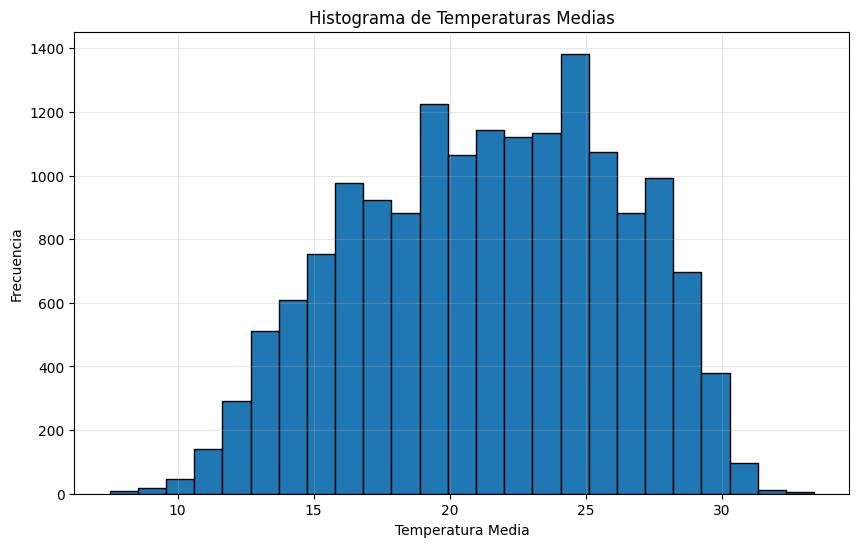

In [10]:
plt.figure(figsize=(10,6))

plt.hist(
    temperatura,
    bins=25,
    edgecolor='black'
)

plt.title('Histograma de Temperaturas Medias')

plt.xlabel('Temperatura Media')

plt.ylabel('Frecuencia')

plt.grid(alpha=0.3)

plt.show()

In [11]:
print('HISTOGRAMA')

print('El histograma muestra la distribucion de las temperaturas medias registradas.')

print('La mayor concentracion de datos se encuentra cerca de la media.')

print('La distribucion presenta un ligero sesgo hacia la izquierda debido a que la media es menor que la mediana.')

print('No se observan concentraciones extremas ni multimodalidad importante.')

print('La dispersion observada coincide con el valor moderado de la desviacion estandar.')

HISTOGRAMA
El histograma muestra la distribucion de las temperaturas medias registradas.
La mayor concentracion de datos se encuentra cerca de la media.
La distribucion presenta un ligero sesgo hacia la izquierda debido a que la media es menor que la mediana.
No se observan concentraciones extremas ni multimodalidad importante.
La dispersion observada coincide con el valor moderado de la desviacion estandar.
